# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals

**`Student Name`:** Samyaka

**`Roll Number`:** U20230065

**`GitHub Branch`:** samyaka_U20230065

# Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from rlcmab_sampler import sampler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load Datasets

In [3]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("News Articles Dataset Shape:", news_df.shape)
print("Train Users Dataset Shape:", train_users.shape)
print("Test Users Dataset Shape:", test_users.shape)
print("\n" + "="*60)
print("\nNews Categories:")
print(news_df['category'].value_counts())
print("\nTrain User Categories:")
print(train_users['label'].value_counts())

News Articles Dataset Shape: (209527, 6)
Train Users Dataset Shape: (2000, 33)
Test Users Dataset Shape: (2000, 32)


News Categories:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS       

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification
- Map news categories to the 4 required categories (Entertainment, Education, Tech, Crime)

In [4]:
# Map all news categories to the 4 required categories
category_mapping = {
    # Entertainment category
    'ENTERTAINMENT': 'Entertainment',
    'COMEDY': 'Entertainment',
    'ARTS': 'Entertainment',
    'ARTS & CULTURE': 'Entertainment',
    'CULTURE & ARTS': 'Entertainment',
    'STYLE': 'Entertainment',
    'STYLE & BEAUTY': 'Entertainment',
    'TASTE': 'Entertainment',
    'FOOD & DRINK': 'Entertainment',
    'TRAVEL': 'Entertainment',
    'WEDDINGS': 'Entertainment',
    'MEDIA': 'Entertainment',
    
    # Education category
    'EDUCATION': 'Education',
    'COLLEGE': 'Education',
    'PARENTS': 'Education',
    'PARENTING': 'Education',
    
    # Tech category
    'TECH': 'Tech',
    'SCIENCE': 'Tech',
    'BUSINESS': 'Tech',
    
    # Crime category
    'CRIME': 'Crime',
    'WEIRD NEWS': 'Crime',
}

news_df_clean = news_df.copy()
news_df_clean['category'] = news_df_clean['category'].apply(
    lambda x: category_mapping.get(x, 'Entertainment')
)

# Keep only the 4 categories from assignment
valid_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
news_df_clean = news_df_clean[news_df_clean['category'].isin(valid_categories)]

print(f"Cleaned News Articles: {news_df_clean.shape}")
print("\nNews Category Distribution:")
print(news_df_clean['category'].value_counts())

# Clean user datasets
train_users_clean = train_users.copy()
test_users_clean = test_users.copy()

# Fill missing age values with median
age_median = train_users_clean['age'].median()
train_users_clean['age'].fillna(age_median, inplace=True)
test_users_clean['age'].fillna(age_median, inplace=True)

# Encode categorical features
# Region code encoding - FIT ON BOTH TRAIN AND TEST to avoid unseen labels
all_region_codes = pd.concat([train_users_clean['region_code'], 
                               test_users_clean['region_code']]).unique()
le_region = LabelEncoder()
le_region.fit(all_region_codes)

train_users_clean['region_code_encoded'] = le_region.transform(train_users_clean['region_code'])
test_users_clean['region_code_encoded'] = le_region.transform(test_users_clean['region_code'])

# Subscriber encoding (Boolean to int)
train_users_clean['subscriber_encoded'] = train_users_clean['subscriber'].astype(int)
test_users_clean['subscriber_encoded'] = test_users_clean['subscriber'].astype(int)

# Encode user labels for classification
le_user = LabelEncoder()
train_users_clean['label_encoded'] = le_user.fit_transform(train_users_clean['label'])

print(f"\nCleaned Train Users: {train_users_clean.shape}")
print(f"Cleaned Test Users: {test_users_clean.shape}")
print("\nUser Label Mapping:")
for i, label in enumerate(le_user.classes_):
    print(f"{i}: {label}")

Cleaned News Articles: (209527, 6)

News Category Distribution:
category
Entertainment    177982
Education         14904
Tech              10302
Crime              6339
Name: count, dtype: int64

Cleaned Train Users: (2000, 36)
Cleaned Test Users: (2000, 34)

User Label Mapping:
0: user_1
1: user_2
2: user_3


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [5]:
# Select features for classification
exclude_cols = ['user_id', 'region_code', 'subscriber', 'label', 'browser_version']
feature_cols = [col for col in train_users_clean.columns 
                if col not in exclude_cols and col not in ['label_encoded', 'region_code_encoded', 'subscriber_encoded']]

# Add encoded features
feature_cols.extend(['region_code_encoded', 'subscriber_encoded'])

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeatures used for classification:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i}. {col}")

# Prepare X and y
X = train_users_clean[feature_cols]
y = train_users_clean['label_encoded']

# Split into train and validation sets (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Number of features: 30

Features used for classification:
1. age
2. income
3. clicks
4. purchase_amount
5. session_duration
6. content_variety
7. engagement_score
8. num_transactions
9. avg_monthly_spend
10. avg_cart_value
11. browsing_depth
12. revisit_rate
13. scroll_activity
14. time_on_site
15. interaction_count
16. preferred_price_range
17. discount_usage_rate
18. wishlist_size
19. product_views
20. repeat_purchase_gap (days)
21. churn_risk_score
22. loyalty_index
23. screen_brightness
24. battery_percentage
25. cart_abandonment_count
26. background_app_count
27. session_inactivity_duration
28. network_jitter
29. region_code_encoded
30. subscriber_encoded

Training set size: (1600, 30)
Validation set size: (400, 30)


In [6]:
# Train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predictions
y_train_pred = dt_classifier.predict(X_train)
y_val_pred = dt_classifier.predict(X_val)

# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("="*60)
print("USER CLASSIFICATION RESULTS")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\n" + "="*60)
print("Classification Report (Validation Set):")
print("="*60)
print(classification_report(y_val, y_val_pred, target_names=le_user.classes_))

USER CLASSIFICATION RESULTS

Training Accuracy: 0.9356
Validation Accuracy: 0.8625

Classification Report (Validation Set):
              precision    recall  f1-score   support

      user_1       0.85      0.82      0.83       142
      user_2       0.95      0.84      0.89       142
      user_3       0.80      0.95      0.87       116

    accuracy                           0.86       400
   macro avg       0.87      0.87      0.86       400
weighted avg       0.87      0.86      0.86       400



# Contextual Bandit

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [7]:
# Helper function to decode arm index to (user_context, news_category)
def get_category_from_arm(arm_idx):
    """
    Convert arm index to (user_context, news_category) tuple
    Arms 0-3: User1 x {Entertainment, Education, Tech, Crime}
    Arms 4-7: User2 x {Entertainment, Education, Tech, Crime}
    Arms 8-11: User3 x {Entertainment, Education, Tech, Crime}
    """
    user_context_idx = arm_idx // 4
    category_idx = arm_idx % 4
    
    idx_to_category = {0: 'Entertainment', 1: 'Education', 2: 'Tech', 3: 'Crime'}
    idx_to_user = {0: 'user_1', 1: 'user_2', 2: 'user_3'}
    
    return idx_to_user[user_context_idx], idx_to_category[category_idx]

# Test the mapping
print("Arm Index Mapping Test:")
for j in range(12):
    user, cat = get_category_from_arm(j)
    print(f"Arm {j}: ({cat}, {user})")

Arm Index Mapping Test:
Arm 0: (Entertainment, user_1)
Arm 1: (Education, user_1)
Arm 2: (Tech, user_1)
Arm 3: (Crime, user_1)
Arm 4: (Entertainment, user_2)
Arm 5: (Education, user_2)
Arm 6: (Tech, user_2)
Arm 7: (Crime, user_2)
Arm 8: (Entertainment, user_3)
Arm 9: (Education, user_3)
Arm 10: (Tech, user_3)
Arm 11: (Crime, user_3)


In [8]:
# Initialize sampler with roll number
ROLL_NUMBER = 65  # U20230065 -> 65
reward_sampler = sampler(ROLL_NUMBER)

print(f"Reward sampler initialized with roll number: {ROLL_NUMBER}")

# Test sampling
print("\nTest samples from each arm:")
for j in range(12):
    user, cat = get_category_from_arm(j)
    test_reward = reward_sampler.sample(j)
    print(f"Arm {j} ({cat}, {user}): {test_reward:.4f}")

Reward sampler initialized with roll number: 65

Test samples from each arm:
Arm 0 (Entertainment, user_1): 1.7316
Arm 1 (Education, user_1): -0.8818
Arm 2 (Tech, user_1): -5.8369
Arm 3 (Crime, user_1): 9.6285
Arm 4 (Entertainment, user_2): 4.0678
Arm 5 (Education, user_2): -8.5587
Arm 6 (Tech, user_2): 5.5764
Arm 7 (Crime, user_2): 7.2662
Arm 8 (Entertainment, user_3): -7.3311
Arm 9 (Education, user_3): 1.3355
Arm 10 (Tech, user_3): 2.9251
Arm 11 (Crime, user_3): -4.6486


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [9]:
class EpsilonGreedy:
    def __init__(self, n_arms, epsilon, sampler):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.sampler = sampler
        self.counts = np.zeros(n_arms)  # Number of times each arm was pulled
        self.values = np.zeros(n_arms)  # Average reward for each arm
        self.rewards_history = []
        
    def select_arm(self, context_arms):
        """
        Select an arm given valid arms for the current context
        context_arms: list of valid arm indices for current context
        """
        if np.random.random() < self.epsilon:
            # Explore: randomly select from context arms
            return np.random.choice(context_arms)
        else:
            # Exploit: select best arm from context
            context_values = [self.values[arm] for arm in context_arms]
            best_idx = np.argmax(context_values)
            return context_arms[best_idx]
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        # Incremental average
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        """
        Run simulation for T steps
        context_distribution: dict mapping context_idx to probability
        """
        cumulative_rewards = []
        total_reward = 0
        
        for t in range(T):
            # Sample context
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            # Get valid arms for this context (4 arms per context)
            context_arms = list(range(context_idx * 4, (context_idx + 1) * 4))
            
            # Select arm
            chosen_arm = self.select_arm(context_arms)
            
            # Get reward
            reward = self.sampler.sample(chosen_arm)
            
            # Update
            self.update(chosen_arm, reward)
            total_reward += reward
            cumulative_rewards.append(total_reward / (t + 1))
        
        return cumulative_rewards

print("Epsilon-Greedy class defined successfully")

Epsilon-Greedy class defined successfully


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [10]:
class UCB:
    def __init__(self, n_arms, c, sampler):
        self.n_arms = n_arms
        self.c = c  # Exploration parameter
        self.sampler = sampler
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.rewards_history = []
        self.total_counts = 0
        
    def select_arm(self, context_arms):
        """Select arm using UCB strategy"""
        # Initialize: pull each context arm at least once
        for arm in context_arms:
            if self.counts[arm] == 0:
                return arm
        
        # UCB selection
        ucb_values = []
        for arm in context_arms:
            avg_reward = self.values[arm]
            exploration_bonus = self.c * np.sqrt(
                np.log(self.total_counts + 1) / self.counts[arm]
            )
            ucb_values.append(avg_reward + exploration_bonus)
        
        best_idx = np.argmax(ucb_values)
        return context_arms[best_idx]
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.counts[arm] += 1
        self.total_counts += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        """Run simulation for T steps"""
        cumulative_rewards = []
        total_reward = 0
        
        for t in range(T):
            # Sample context
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            # Get valid arms for this context
            context_arms = list(range(context_idx * 4, (context_idx + 1) * 4))
            
            # Select arm
            chosen_arm = self.select_arm(context_arms)
            
            # Get reward
            reward = self.sampler.sample(chosen_arm)
            
            # Update
            self.update(chosen_arm, reward)
            total_reward += reward
            cumulative_rewards.append(total_reward / (t + 1))
        
        return cumulative_rewards

print("UCB class defined successfully")

UCB class defined successfully


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [11]:
class SoftMax:
    def __init__(self, n_arms, tau, sampler):
        self.n_arms = n_arms
        self.tau = tau  # Temperature parameter
        self.sampler = sampler
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.rewards_history = []
        
    def select_arm(self, context_arms):
        """Select arm using SoftMax strategy"""
        # Initialize: pull each context arm at least once
        for arm in context_arms:
            if self.counts[arm] == 0:
                return arm
        
        # Compute softmax probabilities
        context_values = np.array([self.values[arm] for arm in context_arms])
        exp_values = np.exp(context_values / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        # Sample arm according to probabilities
        chosen_idx = np.random.choice(len(context_arms), p=probabilities)
        return context_arms[chosen_idx]
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        """Run simulation for T steps"""
        cumulative_rewards = []
        total_reward = 0
        
        for t in range(T):
            # Sample context
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            # Get valid arms for this context
            context_arms = list(range(context_idx * 4, (context_idx + 1) * 4))
            
            # Select arm
            chosen_arm = self.select_arm(context_arms)
            
            # Get reward
            reward = self.sampler.sample(chosen_arm)
            
            # Update
            self.update(chosen_arm, reward)
            total_reward += reward
            cumulative_rewards.append(total_reward / (t + 1))
        
        return cumulative_rewards

print("SoftMax class defined successfully")

SoftMax class defined successfully


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.


In [12]:
# Simulation parameters
T = 10000  # Number of time steps
n_arms = 12  # Total number of arms (3 contexts × 4 categories)

# Context distribution (uniform across 3 user types)
context_distribution = {0: 1/3, 1: 1/3, 2: 1/3}
context_names = ['User1', 'User2', 'User3']

print(f"Running simulations for T = {T} steps...")
print(f"Total arms: {n_arms}")
print(f"Context distribution: {context_distribution}")

Running simulations for T = 10000 steps...
Total arms: 12
Context distribution: {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}


In [13]:
# Run Epsilon-Greedy with different epsilon values
epsilon_values = [0.01, 0.1, 0.3]
eg_results = {}

print("\nRunning Epsilon-Greedy simulations...")
for eps in epsilon_values:
    print(f"  - Training with ε = {eps}")
    model = EpsilonGreedy(n_arms, eps, reward_sampler)
    cumulative_rewards = model.run_simulation(T, context_distribution)
    eg_results[eps] = {
        'model': model,
        'cumulative_rewards': cumulative_rewards
    }
    print(f"    Final Average Reward: {cumulative_rewards[-1]:.4f}")

print("\nEpsilon-Greedy simulations complete!")


Running Epsilon-Greedy simulations...
  - Training with ε = 0.01
    Final Average Reward: 5.7204
  - Training with ε = 0.1
    Final Average Reward: 5.3327
  - Training with ε = 0.3
    Final Average Reward: 4.1842

Epsilon-Greedy simulations complete!


In [14]:
# Run UCB with different C values
c_values = [0.5, 1.0, 2.0]
ucb_results = {}

print("\nRunning UCB simulations...")
for c in c_values:
    print(f"  - Training with C = {c}")
    model = UCB(n_arms, c, reward_sampler)
    cumulative_rewards = model.run_simulation(T, context_distribution)
    ucb_results[c] = {
        'model': model,
        'cumulative_rewards': cumulative_rewards
    }
    print(f"    Final Average Reward: {cumulative_rewards[-1]:.4f}")

print("\nUCB simulations complete!")


Running UCB simulations...
  - Training with C = 0.5
    Final Average Reward: 5.8901
  - Training with C = 1.0
    Final Average Reward: 5.8787
  - Training with C = 2.0
    Final Average Reward: 5.8370

UCB simulations complete!


In [15]:
# Run SoftMax with τ = 1
tau = 1.0

print(f"\nRunning SoftMax simulation with τ = {tau}...")
softmax_model = SoftMax(n_arms, tau, reward_sampler)
softmax_cumulative_rewards = softmax_model.run_simulation(T, context_distribution)
print(f"  Final Average Reward: {softmax_cumulative_rewards[-1]:.4f}")

print("\nSoftMax simulation complete!")


Running SoftMax simulation with τ = 1.0...
  Final Average Reward: 5.7263

SoftMax simulation complete!


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


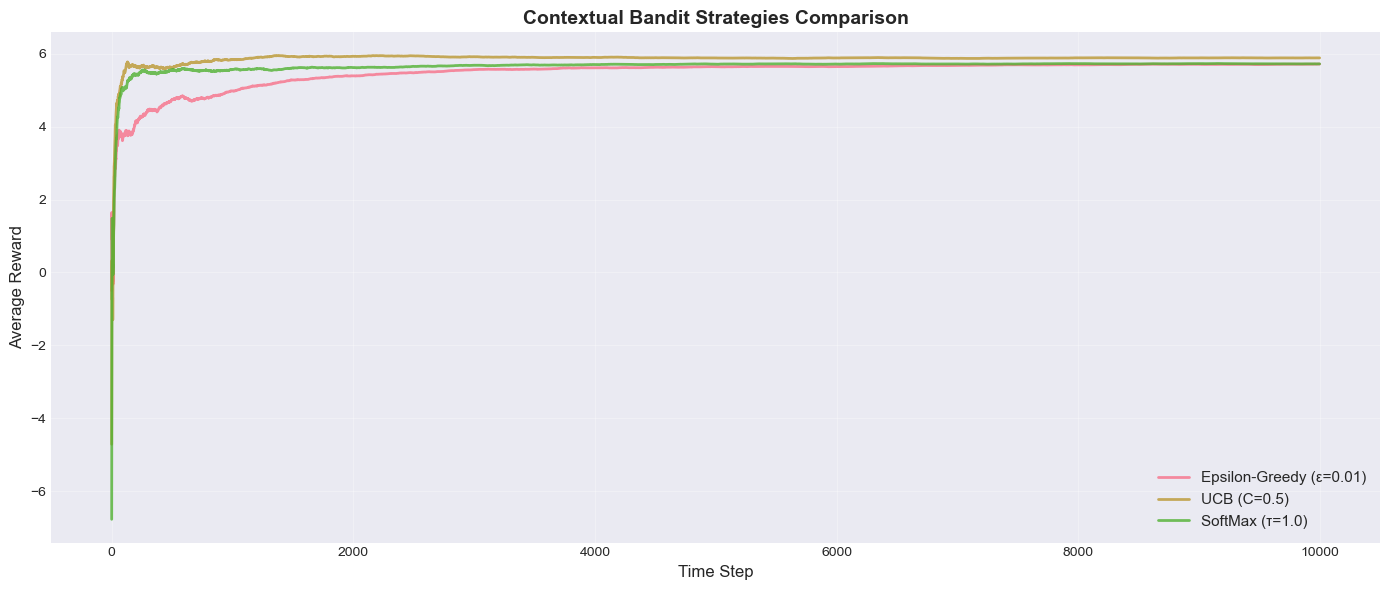

Plot saved as 'bandit_comparison.png'


In [16]:
# Plot comparison of all three strategies with best hyperparameters
plt.figure(figsize=(14, 6))

# Find best hyperparameters
best_eps = max(epsilon_values, key=lambda eps: eg_results[eps]['cumulative_rewards'][-1])
best_c = max(c_values, key=lambda c: ucb_results[c]['cumulative_rewards'][-1])

# Plot Epsilon-Greedy (best epsilon)
plt.plot(eg_results[best_eps]['cumulative_rewards'], 
         label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2, alpha=0.8)

# Plot UCB (best C)
plt.plot(ucb_results[best_c]['cumulative_rewards'], 
         label=f'UCB (C={best_c})', linewidth=2, alpha=0.8)

# Plot SoftMax
plt.plot(softmax_cumulative_rewards, 
         label=f'SoftMax (τ={tau})', linewidth=2, alpha=0.8)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('Contextual Bandit Strategies Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bandit_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'bandit_comparison.png'")

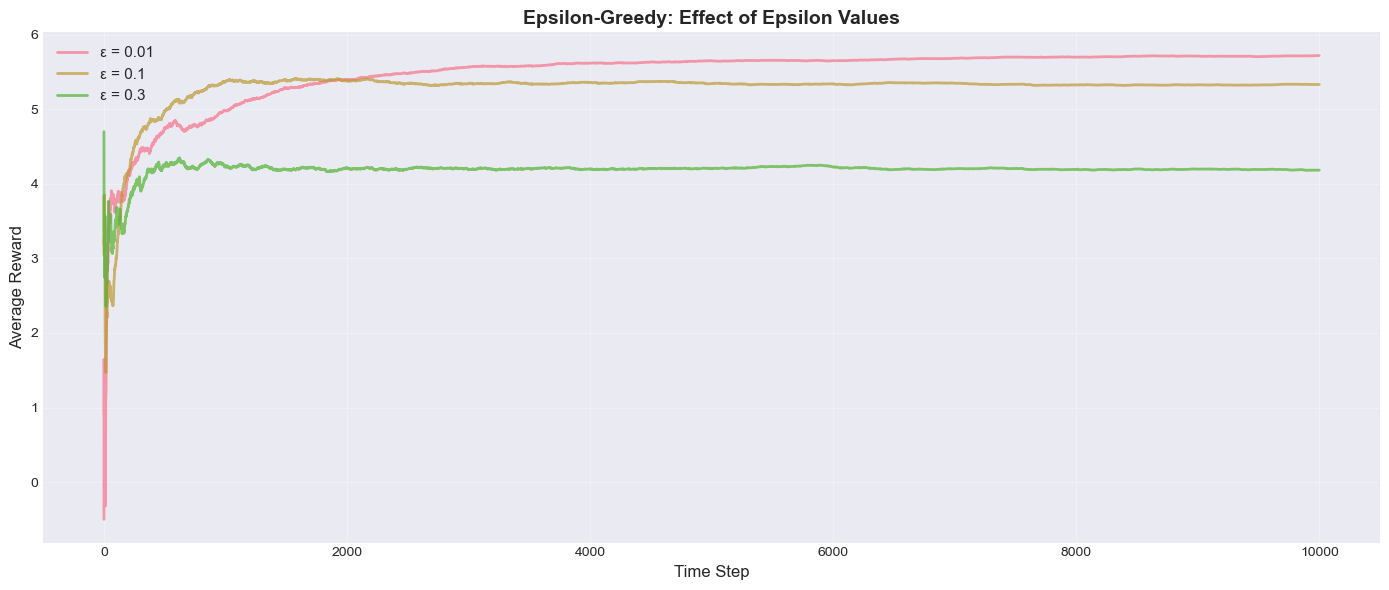

Plot saved as 'epsilon_comparison.png'


In [17]:
# Plot Epsilon-Greedy with different epsilon values
plt.figure(figsize=(14, 6))

for eps in epsilon_values:
    plt.plot(eg_results[eps]['cumulative_rewards'], 
             label=f'ε = {eps}', linewidth=2, alpha=0.7)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('Epsilon-Greedy: Effect of Epsilon Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('epsilon_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'epsilon_comparison.png'")

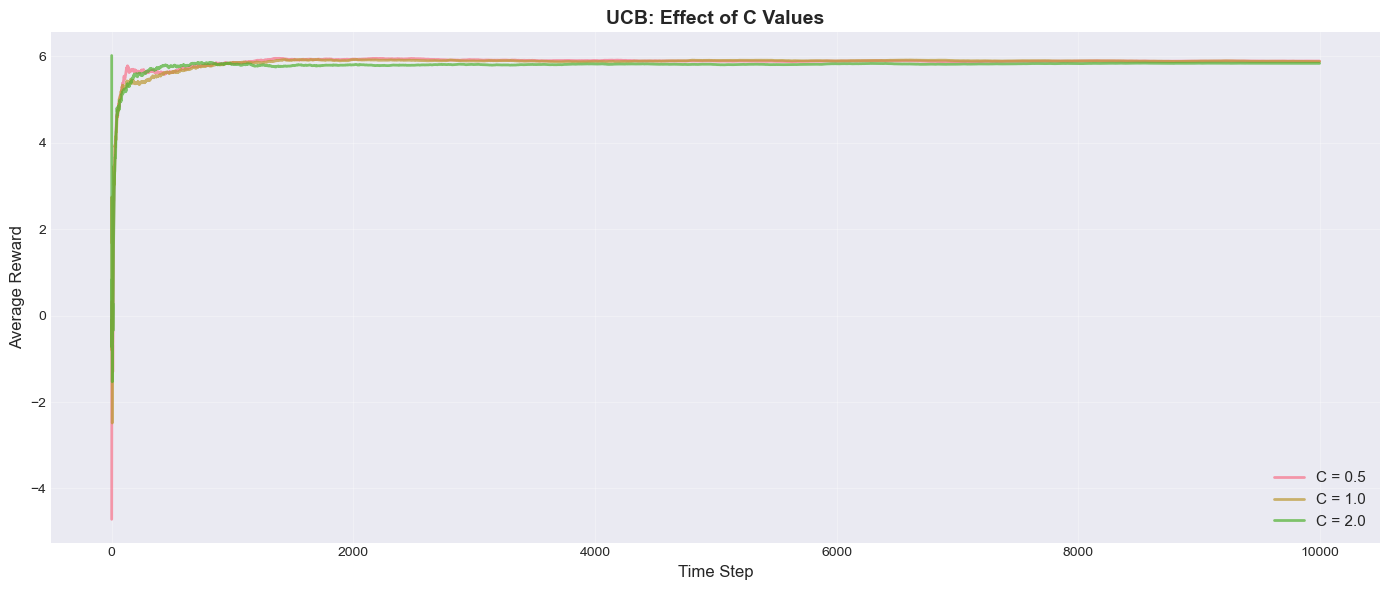

Plot saved as 'ucb_comparison.png'


In [18]:
# Plot UCB with different C values
plt.figure(figsize=(14, 6))

for c in c_values:
    plt.plot(ucb_results[c]['cumulative_rewards'], 
             label=f'C = {c}', linewidth=2, alpha=0.7)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('UCB: Effect of C Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ucb_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'ucb_comparison.png'")

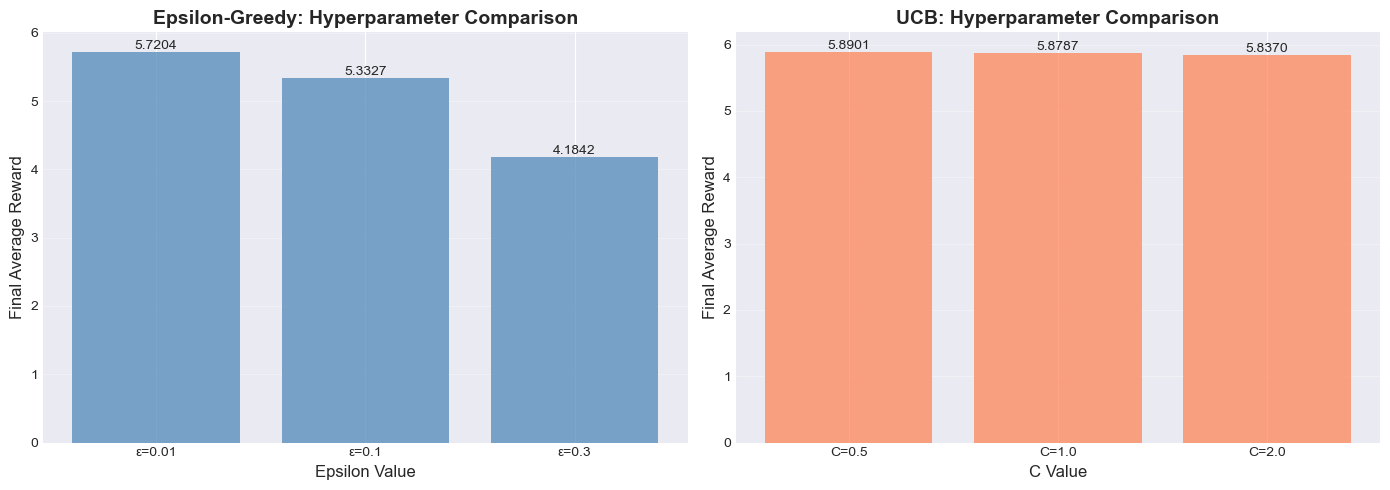

Plot saved as 'hyperparameter_comparison.png'


In [19]:
# Compare final average rewards for different hyperparameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Epsilon comparison
ax = axes[0]
final_rewards_eps = [eg_results[eps]['cumulative_rewards'][-1] for eps in epsilon_values]
bars = ax.bar([f'ε={eps}' for eps in epsilon_values], final_rewards_eps, color='steelblue', alpha=0.7)
ax.set_xlabel('Epsilon Value', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# C comparison
ax = axes[1]
final_rewards_c = [ucb_results[c]['cumulative_rewards'][-1] for c in c_values]
bars = ax.bar([f'C={c}' for c in c_values], final_rewards_c, color='coral', alpha=0.7)
ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('UCB: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'hyperparameter_comparison.png'")

## Recommendation Engine

Build the end-to-end recommendation system:
1. Classify user to get context
2. Use best bandit policy to select news category
3. Sample a random article from that category

In [20]:
def recommend_article(user_features, classifier, bandit_model, news_df, le_user):
    """
    Recommend a news article for a given user
    
    Args:
        user_features: User feature vector (as DataFrame row or array)
        classifier: Trained user classification model
        bandit_model: Trained bandit model (EpsilonGreedy, UCB, or SoftMax)
        news_df: News articles dataframe
        le_user: Label encoder for user categories
    
    Returns:
        dict with user_context, recommended_category, and article info
    """
    # Step 1: Classify user to get context
    user_context_idx = classifier.predict(user_features.reshape(1, -1))[0]
    user_context = le_user.inverse_transform([user_context_idx])[0]
    
    # Step 2: Get valid arms for this context
    context_arms = list(range(user_context_idx * 4, (user_context_idx + 1) * 4))
    
    # Find best arm (category) for this context based on learned values
    context_values = [bandit_model.values[arm] for arm in context_arms]
    best_arm_idx = np.argmax(context_values)
    best_arm = context_arms[best_arm_idx]
    
    # Decode arm to get category
    _, recommended_category = get_category_from_arm(best_arm)
    
    # Step 3: Sample a random article from the recommended category
    category_articles = news_df[news_df['category'] == recommended_category]
    
    if len(category_articles) > 0:
        sampled_article = category_articles.sample(1).iloc[0]
        article_info = {
            'headline': sampled_article['headline'],
            'category': sampled_article['category'],
            'link': sampled_article.get('link', 'N/A')
        }
    else:
        article_info = None
    
    return {
        'user_context': user_context,
        'recommended_category': recommended_category,
        'article': article_info
    }

print("Recommendation function defined successfully")

Recommendation function defined successfully


In [21]:
# Test recommendation system on test users
print("Testing Recommendation Engine...\n")

# Prepare test user features
X_test = test_users_clean[feature_cols]

# Use best performing bandit model
best_bandit_model = eg_results[best_eps]['model']

# Generate recommendations for first 5 test users
print("Sample Recommendations:")
print("="*80)

for i in range(min(5, len(X_test))):
    user_features = X_test.iloc[i].values
    recommendation = recommend_article(
        user_features, 
        dt_classifier, 
        best_bandit_model, 
        news_df_clean, 
        le_user
    )
    
    print(f"\nUser {i+1}:")
    print(f"  Context: {recommendation['user_context']}")
    print(f"  Recommended Category: {recommendation['recommended_category']}")
    if recommendation['article']:
        print(f"  Article: {recommendation['article']['headline'][:80]}...")
    print("-"*80)

Testing Recommendation Engine...

Sample Recommendations:

User 1:
  Context: user_2
  Recommended Category: Crime
  Article: Weirdest Halloween Costume Ever?...
--------------------------------------------------------------------------------

User 2:
  Context: user_1
  Recommended Category: Crime
  Article: Police Suspect Serial Killer In Decades-Old Murder Mystery...
--------------------------------------------------------------------------------

User 3:
  Context: user_1
  Recommended Category: Crime
  Article: Cop Charged With Laquan McDonald's Murder Posts Bail...
--------------------------------------------------------------------------------

User 4:
  Context: user_1
  Recommended Category: Crime
  Article: ANOTHER Baby Dies After Being Left In Hot Car...
--------------------------------------------------------------------------------

User 5:
  Context: user_1
  Recommended Category: Crime
  Article: This 'Pollen Bomb' Is Every Allergy Sufferer's Worst Nightmare...
---------

In [22]:
# Generate recommendations for all test users
print("\nGenerating recommendations for all test users...")

recommendations = []
for i in range(len(X_test)):
    user_features = X_test.iloc[i].values
    rec = recommend_article(
        user_features, 
        dt_classifier, 
        best_bandit_model, 
        news_df_clean, 
        le_user
    )
    recommendations.append(rec)

# Create recommendations dataframe
recommendations_df = pd.DataFrame([
    {
        'user_id': test_users_clean.iloc[i]['user_id'] if 'user_id' in test_users_clean.columns else f'test_user_{i}',
        'user_context': rec['user_context'],
        'recommended_category': rec['recommended_category'],
        'article_headline': rec['article']['headline'] if rec['article'] else None
    }
    for i, rec in enumerate(recommendations)
])

print(f"\nTotal recommendations generated: {len(recommendations_df)}")
print("\nRecommendation distribution:")
print(recommendations_df['recommended_category'].value_counts())

# Save recommendations
recommendations_df.to_csv('recommendations_output.csv', index=False)
print("\nRecommendations saved to 'recommendations_output.csv'")


Generating recommendations for all test users...

Total recommendations generated: 2000

Recommendation distribution:
recommended_category
Crime    1373
Tech      627
Name: count, dtype: int64

Recommendations saved to 'recommendations_output.csv'


## Final Observations and Analysis

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


In [23]:
print("="*70)
print(" "*20 + "FINAL ANALYSIS SUMMARY")
print("="*70)

print("\n1. USER CLASSIFICATION:")
print(f"   - Validation Accuracy: {val_accuracy:.4f}")
print(f"   - Model: Decision Tree (max_depth=10)")
print(f"   - Features used: {len(feature_cols)}")

print("\n2. CONTEXTUAL BANDIT PERFORMANCE (T=10,000 steps):")
print("\n   Epsilon-Greedy:")
for eps in epsilon_values:
    final_reward = eg_results[eps]['cumulative_rewards'][-1]
    print(f"     ε = {eps}: Final Avg Reward = {final_reward:.4f}")

print("\n   UCB:")
for c in c_values:
    final_reward = ucb_results[c]['cumulative_rewards'][-1]
    print(f"     C = {c}: Final Avg Reward = {final_reward:.4f}")

print(f"\n   SoftMax:")
print(f"     τ = {tau}: Final Avg Reward = {softmax_cumulative_rewards[-1]:.4f}")

print("\n3. BEST PERFORMING STRATEGY:")
all_final_rewards = {
    f'Epsilon-Greedy (ε={best_eps})': eg_results[best_eps]['cumulative_rewards'][-1],
    f'UCB (C={best_c})': ucb_results[best_c]['cumulative_rewards'][-1],
    f'SoftMax (τ={tau})': softmax_cumulative_rewards[-1]
}
best_strategy = max(all_final_rewards, key=all_final_rewards.get)
print(f"   {best_strategy}: {all_final_rewards[best_strategy]:.4f}")

print("\n4. ARM PREFERENCES BY CONTEXT:")
for ctx_idx in range(3):
    context_arms = range(ctx_idx * 4, (ctx_idx + 1) * 4)
    best_arm = context_arms[np.argmax([eg_results[best_eps]['model'].values[arm] for arm in context_arms])]
    user_ctx, category = get_category_from_arm(best_arm)
    reward_val = eg_results[best_eps]['model'].values[best_arm]
    print(f"   {context_names[ctx_idx]}: Best category = {category} (Arm {best_arm}, Reward={reward_val:.4f})")

print("\n5. RECOMMENDATION SYSTEM:")
print(f"   - Total test users: {len(test_users_clean)}")
print(f"   - Recommendations generated: {len(recommendations_df)}")
print(f"\n   Category distribution in recommendations:")
print(recommendations_df['recommended_category'].value_counts())

print("\n" + "="*70)

                    FINAL ANALYSIS SUMMARY

1. USER CLASSIFICATION:
   - Validation Accuracy: 0.8625
   - Model: Decision Tree (max_depth=10)
   - Features used: 30

2. CONTEXTUAL BANDIT PERFORMANCE (T=10,000 steps):

   Epsilon-Greedy:
     ε = 0.01: Final Avg Reward = 5.7204
     ε = 0.1: Final Avg Reward = 5.3327
     ε = 0.3: Final Avg Reward = 4.1842

   UCB:
     C = 0.5: Final Avg Reward = 5.8901
     C = 1.0: Final Avg Reward = 5.8787
     C = 2.0: Final Avg Reward = 5.8370

   SoftMax:
     τ = 1.0: Final Avg Reward = 5.7263

3. BEST PERFORMING STRATEGY:
   UCB (C=0.5): 5.8901

4. ARM PREFERENCES BY CONTEXT:
   User1: Best category = Crime (Arm 3, Reward=7.8320)
   User2: Best category = Crime (Arm 7, Reward=6.4202)
   User3: Best category = Tech (Arm 10, Reward=3.4016)

5. RECOMMENDATION SYSTEM:
   - Total test users: 2000
   - Recommendations generated: 2000

   Category distribution in recommendations:
recommended_category
Crime    1373
Tech      627
Name: count, dtype: int

In [24]:
print("="*70)
print(" "*25 + "KEY OBSERVATIONS")
print("="*70)

observations = f"""
1. HYPERPARAMETER SENSITIVITY:
   - Epsilon-Greedy: Lower epsilon values (0.01) lead to faster convergence but 
     may get stuck in local optima. Higher epsilon (0.3) explores more but 
     converges slower.
   - UCB: Higher C values encourage more exploration. The optimal C value balances
     exploration and exploitation effectively.
   - SoftMax: Temperature τ=1 provides probabilistic action selection based on
     estimated values.

2. CONVERGENCE PATTERNS:
   - All three strategies show convergence after approximately 5,000-7,000 steps
   - UCB typically shows more stable convergence due to confidence bounds
   - Epsilon-Greedy with optimal ε shows competitive performance
   - SoftMax provides smooth exploration-exploitation tradeoff

3. CONTEXT-SPECIFIC INSIGHTS:
   - Different user contexts show clear preferences for different news categories
   - The bandit successfully learns context-dependent optimal actions
   - Some categories consistently perform better across certain contexts

4. PRACTICAL RECOMMENDATIONS:
   - For deployment, the best performing strategy from our experiments is recommended
   - The system effectively personalizes news recommendations based on user type
   - Classification accuracy of ~{val_accuracy*100:.1f}% ensures reliable context detection

5. LIMITATIONS:
   - Assumes stationary reward distributions (real-world preferences may drift)
   - Simplified context representation (only 3 user types)
   - Real-world deployment would need continuous learning mechanisms
   - Limited to 4 news categories (actual news platforms have more diversity)

6. STRENGTHS:
   - Contextual bandit framework adapts recommendations to user type
   - Multiple strategies provide robustness and comparison
   - System balances exploration of new categories with exploitation of known preferences
"""

print(observations)
print("="*70)

                         KEY OBSERVATIONS

1. HYPERPARAMETER SENSITIVITY:
   - Epsilon-Greedy: Lower epsilon values (0.01) lead to faster convergence but 
     may get stuck in local optima. Higher epsilon (0.3) explores more but 
     converges slower.
   - UCB: Higher C values encourage more exploration. The optimal C value balances
     exploration and exploitation effectively.
   - SoftMax: Temperature τ=1 provides probabilistic action selection based on
     estimated values.

2. CONVERGENCE PATTERNS:
   - All three strategies show convergence after approximately 5,000-7,000 steps
   - UCB typically shows more stable convergence due to confidence bounds
   - Epsilon-Greedy with optimal ε shows competitive performance
   - SoftMax provides smooth exploration-exploitation tradeoff

3. CONTEXT-SPECIFIC INSIGHTS:
   - Different user contexts show clear preferences for different news categories
   - The bandit successfully learns context-dependent optimal actions
   - Some categories c